# DBS Artifact Removal Benchmark (Production)

This notebook builds an end-to-end benchmark for DBS artifact removal in resting-state EEG and compares five methods:

1. Method A: Parametric Comb Notch
2. Method B: Phase-Locked Template Subtraction (Moving Average)
3. Method C: Frequency-Domain Hampel
4. Method D: ZapLine-Equivalent Spatial Projection
5. Method E: 1D-CNN Denoising Autoencoder (PyTorch)

All methods are evaluated against a DBS OFF recording used as physiological ground truth.

In [50]:
import os
import sys
import time
import random
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.ndimage import uniform_filter1d

import mne


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / "src").exists() and (p / "data").exists():
            return p
    raise RuntimeError("Could not locate repository root containing src/ and data/")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.preprocessing import EEGPreprocessor
from src.filters import ArtifactFilterFactory

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
except Exception as e:
    raise RuntimeError(
        "PyTorch is required for Method E. Install with `pip install torch` in your environment."
    ) from e

SEED = 97
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")

plt.style.use("seaborn-v0_8-whitegrid")
mne.set_log_level("WARNING")

print("Environment ready")
print(f"Repo root: {REPO_ROOT}")
print(f"MNE: {mne.__version__}")
print(f"Torch: {torch.__version__}")
print(f"Device: {device}")

Environment ready
Repo root: /Users/student/Workspace/ml-driven-eeg-biomarkers
MNE: 1.10.2
Torch: 2.2.2
Device: cpu


In [51]:
@dataclass
class BenchmarkConfig:
    on_path: Path = REPO_ROOT / "data/raw/XU/XUAWAKE7_deidentified.edf"
    off_path: Path = REPO_ROOT / "data/raw/XU/XUAWAKEPRE_deidentified.edf"
    montage: str = "standard_1020"
    l_freq: float = 1.0
    h_freq: float = 120.0
    dbs_freq: float = 7.0
    target_channel: str = "Fp1"

    # Method A
    comb_q: float = 35.0

    # Method B
    template_window_cycles: int = 20

    # Method C
    hampel_window_hz: float = 2.0
    hampel_n_sigmas: float = 3.0
    hampel_atten_db: float = -60.0

    # Method D
    zap_n_harmonics: int = 12
    zap_threshold_percentile: float = 95.0

    # Method E
    win_sec: float = 2.0
    hop_sec: float = 1.0
    batch_size: int = 32
    epochs: int = 8
    lr: float = 1e-3
    spectral_loss_weight: float = 0.2

    # ICA
    emg_hf_threshold_hz: float = 20.0
    emg_z_thresh: float = 2.5

    # Outputs
    out_fig_dir: Path = REPO_ROOT / "results/figures/dbs_benchmark"
    out_metrics_dir: Path = REPO_ROOT / "results/metrics"

cfg = BenchmarkConfig()
cfg.out_fig_dir.mkdir(parents=True, exist_ok=True)
cfg.out_metrics_dir.mkdir(parents=True, exist_ok=True)

print(pd.Series(asdict(cfg), dtype=object))

on_path                     /Users/student/Workspace/ml-driven-eeg-biomark...
off_path                    /Users/student/Workspace/ml-driven-eeg-biomark...
montage                                                         standard_1020
l_freq                                                                    1.0
h_freq                                                                  120.0
dbs_freq                                                                  7.0
target_channel                                                            Fp1
comb_q                                                                   35.0
template_window_cycles                                                     20
hampel_window_hz                                                          2.0
hampel_n_sigmas                                                           3.0
hampel_atten_db                                                         -60.0
zap_n_harmonics                                                 

In [52]:
def load_and_prepare_raws(cfg: BenchmarkConfig) -> Tuple[mne.io.Raw, mne.io.Raw]:
    if not cfg.on_path.exists():
        raise FileNotFoundError(f"Missing DBS ON file: {cfg.on_path}")
    if not cfg.off_path.exists():
        raise FileNotFoundError(f"Missing DBS OFF file: {cfg.off_path}")

    raw_on = mne.io.read_raw_edf(cfg.on_path, preload=True, verbose="WARNING")
    raw_off = mne.io.read_raw_edf(cfg.off_path, preload=True, verbose="WARNING")

    pre = EEGPreprocessor(l_freq=cfg.l_freq, h_freq=cfg.h_freq)
    raw_on = pre.standardize_channels(raw_on)
    raw_off = pre.standardize_channels(raw_off)

    # Channel intersection/order alignment.
    common = [ch for ch in raw_on.ch_names if ch in raw_off.ch_names]
    if len(common) < 8:
        raise ValueError(f"Too few common channels after standardization: {len(common)}")

    raw_on.pick(common)
    raw_off.pick(common)

    sfreq = min(raw_on.info["sfreq"], raw_off.info["sfreq"])
    if abs(raw_on.info["sfreq"] - sfreq) > 1e-6:
        raw_on.resample(sfreq)
    if abs(raw_off.info["sfreq"] - sfreq) > 1e-6:
        raw_off.resample(sfreq)

    nyq = sfreq / 2.0
    h_eff = min(cfg.h_freq, nyq - 0.5)
    if h_eff <= cfg.l_freq:
        raise ValueError(f"Invalid filter bounds with sfreq={sfreq}: l={cfg.l_freq}, h={h_eff}")

    raw_on.filter(cfg.l_freq, h_eff, fir_design="firwin", phase="zero", verbose="WARNING")
    raw_off.filter(cfg.l_freq, h_eff, fir_design="firwin", phase="zero", verbose="WARNING")

    n = min(raw_on.n_times, raw_off.n_times)
    raw_on.crop(tmin=0.0, tmax=(n - 1) / sfreq)
    raw_off.crop(tmin=0.0, tmax=(n - 1) / sfreq)

    return raw_on, raw_off


def raw_from_data(template_raw: mne.io.Raw, data: np.ndarray) -> mne.io.Raw:
    out = template_raw.copy()
    out._data = data.astype(np.float64, copy=False)
    return out


def get_plot_channel(ch_names: List[str], target: str) -> str:
    if target in ch_names:
        return target
    fallback = ["Fp1", "Fp2", "F3", "F4", "Cz", ch_names[0]]
    for ch in fallback:
        if ch in ch_names:
            return ch
    return ch_names[0]


raw_on, raw_off = load_and_prepare_raws(cfg)
plot_ch = get_plot_channel(raw_on.ch_names, cfg.target_channel)
print(f"Prepared ON/OFF with {len(raw_on.ch_names)} channels, sfreq={raw_on.info['sfreq']:.2f} Hz, duration={raw_on.times[-1]:.1f}s")
print(f"Plot channel: {plot_ch}")

Prepared ON/OFF with 19 channels, sfreq=200.00 Hz, duration=568.0s
Plot channel: Fp1


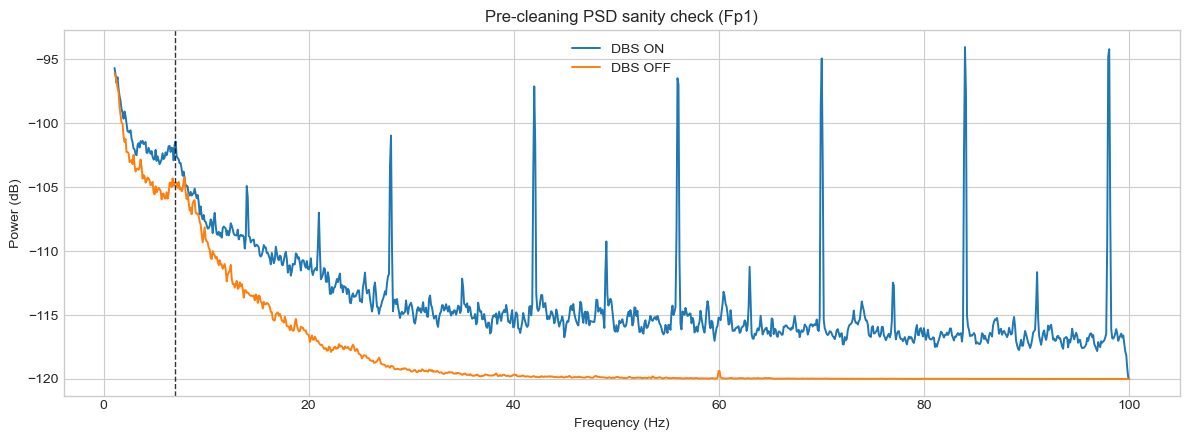

In [53]:
# Pre-cleaning quality-control preview.
sfreq = raw_on.info["sfreq"]
idx = raw_on.ch_names.index(plot_ch)

plt.figure(figsize=(12, 4.5))
f_on, p_on = signal.welch(raw_on.get_data(picks=[idx])[0], fs=sfreq, nperseg=min(2048, raw_on.n_times))
f_off, p_off = signal.welch(raw_off.get_data(picks=[idx])[0], fs=sfreq, nperseg=min(2048, raw_off.n_times))

mask = (f_on >= 1.0) & (f_on <= 120.0)
plt.plot(f_on[mask], 10 * np.log10(p_on[mask] + 1e-12), label="DBS ON", lw=1.4)
plt.plot(f_off[mask], 10 * np.log10(p_off[mask] + 1e-12), label="DBS OFF", lw=1.4)
plt.axvline(cfg.dbs_freq, color="k", ls="--", lw=1.0, alpha=0.8)
plt.title(f"Pre-cleaning PSD sanity check ({plot_ch})")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (dB)")
plt.legend()
plt.tight_layout()
plt.show()

In [54]:
def build_time_sync_windows(x_on: np.ndarray, x_off: np.ndarray, win: int, hop: int) -> Tuple[np.ndarray, np.ndarray]:
    n = min(x_on.shape[1], x_off.shape[1])
    x_on = x_on[:, :n]
    x_off = x_off[:, :n]
    starts = np.arange(0, n - win + 1, hop)
    x = np.stack([x_on[:, s:s+win] for s in starts], axis=0)
    y = np.stack([x_off[:, s:s+win] for s in starts], axis=0)
    return x, y


def _window_psd_feature(w: np.ndarray, sfreq: float) -> np.ndarray:
    f, p = signal.welch(w, fs=sfreq, nperseg=min(256, w.shape[1]), axis=1)
    band = (f >= 1.0) & (f <= 120.0)
    return np.log10(p[:, band].mean(axis=0) + 1e-12)


def build_psd_matched_windows(x_on: np.ndarray, x_off: np.ndarray, sfreq: float, win: int, hop: int) -> Tuple[np.ndarray, np.ndarray]:
    starts_on = np.arange(0, x_on.shape[1] - win + 1, hop)
    starts_off = np.arange(0, x_off.shape[1] - win + 1, hop)

    on_windows = [x_on[:, s:s+win] for s in starts_on]
    off_windows = [x_off[:, s:s+win] for s in starts_off]
    off_feats = np.stack([_window_psd_feature(w, sfreq) for w in off_windows], axis=0)

    x_list, y_list = [], []
    for w_on in on_windows:
        f_on = _window_psd_feature(w_on, sfreq)
        d = np.linalg.norm(off_feats - f_on[None, :], axis=1)
        j = int(np.argmin(d))
        x_list.append(w_on)
        y_list.append(off_windows[j])

    return np.stack(x_list, axis=0), np.stack(y_list, axis=0)


def build_hybrid_windows(x_on: np.ndarray, x_off: np.ndarray, sfreq: float, win: int, hop: int) -> Tuple[np.ndarray, np.ndarray, Dict[str, int]]:
    x_sync, y_sync = build_time_sync_windows(x_on, x_off, win=win, hop=hop)
    x_psd, y_psd = build_psd_matched_windows(x_on, x_off, sfreq=sfreq, win=win, hop=hop)

    n_sync = len(x_sync)
    n_psd = len(x_psd)
    n_mix = min(n_sync, n_psd)

    x = np.concatenate([x_sync, x_psd[:n_mix]], axis=0)
    y = np.concatenate([y_sync, y_psd[:n_mix]], axis=0)
    meta = {"n_sync": int(n_sync), "n_psd": int(n_psd), "n_mix": int(n_mix)}
    return x, y, meta


class UNet3D_1D(nn.Module):
    """3-level encoder-decoder U-Net for 1D EEG denoising with multiscale receptive fields."""
    def __init__(self, n_channels: int):
        super().__init__()

        def block(in_ch: int, out_ch: int) -> nn.Sequential:
            return nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=7, padding=3),
                nn.GroupNorm(max(1, out_ch // 8), out_ch),
                nn.GELU(),
                nn.Conv1d(out_ch, out_ch, kernel_size=5, padding=2),
                nn.GroupNorm(max(1, out_ch // 8), out_ch),
                nn.GELU(),
            )

        # 3-level encoder
        self.enc1 = block(n_channels, 16)
        self.pool1 = nn.AvgPool1d(kernel_size=2, stride=2)
        self.enc2 = block(16, 32)
        self.pool2 = nn.AvgPool1d(kernel_size=2, stride=2)
        self.enc3 = block(32, 64)
        self.pool3 = nn.AvgPool1d(kernel_size=2, stride=2)

        # Bottleneck at deepest level
        self.bottleneck = nn.Sequential(
            nn.Conv1d(64, 96, kernel_size=5, padding=2),
            nn.GroupNorm(12, 96),
            nn.GELU(),
            nn.Conv1d(96, 96, kernel_size=3, padding=1),
            nn.GroupNorm(12, 96),
            nn.GELU(),
            nn.Conv1d(96, 64, kernel_size=3, padding=1),
            nn.GroupNorm(8, 64),
            nn.GELU(),
        )

        # 3-level decoder with skip connections
        self.up3 = nn.ConvTranspose1d(64, 32, kernel_size=2, stride=2)
        self.dec3 = block(32 + 64, 32)  # concatenate skip from enc3
        self.up2 = nn.ConvTranspose1d(32, 16, kernel_size=2, stride=2)
        self.dec2 = block(16 + 32, 16)  # concatenate skip from enc2
        self.up1 = nn.ConvTranspose1d(16, 16, kernel_size=2, stride=2)
        self.dec1 = block(16 + 16, 16)  # concatenate skip from enc1
        self.out = nn.Conv1d(16, n_channels, kernel_size=1)

    @staticmethod
    def _match_length(x: torch.Tensor, ref: torch.Tensor) -> torch.Tensor:
        if x.shape[-1] == ref.shape[-1]:
            return x
        if x.shape[-1] > ref.shape[-1]:
            return x[..., :ref.shape[-1]]
        pad = ref.shape[-1] - x.shape[-1]
        return torch.nn.functional.pad(x, (0, pad))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        
        # Encoder
        s1 = self.enc1(x)
        x = self.pool1(s1)
        
        s2 = self.enc2(x)
        x = self.pool2(s2)
        
        s3 = self.enc3(x)
        x = self.pool3(s3)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder with skip connections
        x = self.up3(x)
        x = self._match_length(x, s3)
        x = torch.cat([x, s3], dim=1)
        x = self.dec3(x)
        
        x = self.up2(x)
        x = self._match_length(x, s2)
        x = torch.cat([x, s2], dim=1)
        x = self.dec2(x)
        
        x = self.up1(x)
        x = self._match_length(x, s1)
        x = torch.cat([x, s1], dim=1)
        x = self.dec1(x)
        
        out = self.out(x)
        if residual.shape[-1] != out.shape[-1]:
            residual = residual[..., :out.shape[-1]]
        return out + 0.3 * residual  # Residual connection with slight weighting


class DenoiseAE1D(UNet3D_1D):
    pass


def spectral_loss(pred: torch.Tensor, target: torch.Tensor, sfreq: float) -> torch.Tensor:
    p_fft = torch.fft.rfft(pred, dim=-1)
    t_fft = torch.fft.rfft(target, dim=-1)
    freqs = torch.fft.rfftfreq(pred.shape[-1], d=1.0 / sfreq).to(pred.device)

    band_main = (freqs >= 4.0) & (freqs <= 15.0)
    band_near = (freqs >= 1.0) & (freqs <= 40.0)

    p_mag = torch.abs(p_fft)
    t_mag = torch.abs(t_fft)

    main_loss = torch.mean((torch.log1p(p_mag[..., band_main]) - torch.log1p(t_mag[..., band_main])) ** 2)
    near_loss = torch.mean((torch.log1p(p_mag[..., band_near]) - torch.log1p(t_mag[..., band_near])) ** 2)
    return 0.7 * main_loss + 0.3 * near_loss


def band_preservation_loss(pred: torch.Tensor, target: torch.Tensor, sfreq: float) -> torch.Tensor:
    p_fft = torch.fft.rfft(pred, dim=-1)
    t_fft = torch.fft.rfft(target, dim=-1)
    freqs = torch.fft.rfftfreq(pred.shape[-1], d=1.0 / sfreq).to(pred.device)

    theta = (freqs >= 4.0) & (freqs <= 8.0)
    alpha = (freqs >= 8.0) & (freqs <= 13.0)

    theta_loss = torch.mean((torch.abs(p_fft[..., theta]) - torch.abs(t_fft[..., theta])) ** 2)
    alpha_loss = torch.mean((torch.abs(p_fft[..., alpha]) - torch.abs(t_fft[..., alpha])) ** 2)
    return theta_loss + alpha_loss


def harmonic_avoidance_loss(pred: torch.Tensor, target: torch.Tensor, sfreq: float, dbs_freq: float = 7.0, harmonic_width_hz: float = 1.0) -> torch.Tensor:
    """Penalize deviations in the DBS harmonic region to avoid suppressing the target frequency."""
    p_fft = torch.fft.rfft(pred, dim=-1)
    t_fft = torch.fft.rfft(target, dim=-1)
    freqs = torch.fft.rfftfreq(pred.shape[-1], d=1.0 / sfreq).to(pred.device)

    # Target the fundamental and first few harmonics
    harmonics_mask = torch.zeros_like(freqs, dtype=torch.bool)
    for n in range(1, 4):  # 1st, 2nd, 3rd harmonics
        f_center = n * dbs_freq
        harmonic_band = (freqs >= f_center - harmonic_width_hz) & (freqs <= f_center + harmonic_width_hz)
        harmonics_mask = harmonics_mask | harmonic_band

    if not torch.any(harmonics_mask):
        return torch.tensor(0.0, dtype=pred.dtype, device=pred.device)

    p_mag = torch.abs(p_fft[..., harmonics_mask])
    t_mag = torch.abs(t_fft[..., harmonics_mask])
    return torch.mean((p_mag - t_mag) ** 2)


def to_torch(x: np.ndarray) -> torch.Tensor:
    return torch.tensor(x.tolist(), dtype=torch.float32)


def standardize_window_pair(x: torch.Tensor, y: torch.Tensor, eps: float = 1e-6) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    mean = x.mean(dim=-1, keepdim=True)
    std = x.std(dim=-1, keepdim=True).clamp_min(eps)
    return (x - mean) / std, (y - mean) / std, mean, std


def train_dae_method_e(raw_on: mne.io.Raw, raw_off: mne.io.Raw, cfg: BenchmarkConfig) -> Tuple[mne.io.Raw, Dict[str, float]]:
    sfreq = raw_on.info["sfreq"]
    x_on = raw_on.get_data().astype(np.float32)
    x_off = raw_off.get_data().astype(np.float32)

    win = int(round(cfg.win_sec * sfreq))
    hop = int(round(cfg.hop_sec * sfreq))
    if win <= 16 or hop <= 0:
        raise ValueError("Invalid win/hop for Method E")

    x_mix, y_mix, mix_meta = build_hybrid_windows(x_on, x_off, sfreq=sfreq, win=win, hop=hop)
    pairing = "hybrid-sync+psd"

    idx = np.arange(x_mix.shape[0])
    np.random.shuffle(idx)
    split = max(1, int(0.8 * len(idx)))
    tr_idx, va_idx = idx[:split], idx[split:]
    if len(va_idx) == 0:
        va_idx = tr_idx[: min(4, len(tr_idx))]

    x_tr = to_torch(x_mix[tr_idx])
    y_tr = to_torch(y_mix[tr_idx])
    x_va = to_torch(x_mix[va_idx])
    y_va = to_torch(y_mix[va_idx])

    tr_loader = DataLoader(TensorDataset(x_tr, y_tr), batch_size=cfg.batch_size, shuffle=True, drop_last=False)
    va_loader = DataLoader(TensorDataset(x_va, y_va), batch_size=cfg.batch_size, shuffle=False, drop_last=False)

    model = DenoiseAE1D(n_channels=x_on.shape[0]).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=1e-4)
    mse = nn.SmoothL1Loss(beta=0.5)

    best_state = None
    best_val = np.inf
    patience = 4
    stale = 0

    # Reduced spectral_loss_weight to 0.5 to favor waveform fidelity
    spectral_w = 0.5
    band_pres_w = 0.25
    harmonic_w = 0.15

    for ep in range(cfg.epochs):
        model.train()
        tr_losses = []
        for xb, yb in tr_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            xb_n, yb_n, _, _ = standardize_window_pair(xb, yb)
            pred = model(xb_n)
            loss = (
                mse(pred, yb_n)
                + spectral_w * spectral_loss(pred, yb_n, sfreq)
                + band_pres_w * band_preservation_loss(pred, yb_n, sfreq)
                + harmonic_w * harmonic_avoidance_loss(pred, yb_n, sfreq, dbs_freq=cfg.dbs_freq, harmonic_width_hz=1.0)
            )
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_losses.append(float(loss.item()))

        model.eval()
        va_losses = []
        with torch.no_grad():
            for xb, yb in va_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                xb_n, yb_n, _, _ = standardize_window_pair(xb, yb)
                pred = model(xb_n)
                loss = (
                    mse(pred, yb_n)
                    + spectral_w * spectral_loss(pred, yb_n, sfreq)
                    + band_pres_w * band_preservation_loss(pred, yb_n, sfreq)
                    + harmonic_w * harmonic_avoidance_loss(pred, yb_n, sfreq, dbs_freq=cfg.dbs_freq, harmonic_width_hz=1.0)
                )
                va_losses.append(float(loss.item()))

        tr_mean = float(np.mean(tr_losses)) if tr_losses else np.nan
        va_mean = float(np.mean(va_losses)) if va_losses else np.nan
        print(f"Epoch {ep+1:02d}: train={tr_mean:.6f}, val={va_mean:.6f}")

        if va_mean < best_val:
            best_val = va_mean
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                print("Early stopping triggered")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    starts = np.arange(0, x_on.shape[1] - win + 1, hop)
    recon = np.zeros_like(x_on, dtype=np.float32)
    weight = np.zeros_like(x_on, dtype=np.float32)
    window_weight = np.hanning(win).astype(np.float32)
    window_weight[window_weight < 1e-3] = 1e-3

    model.eval()
    with torch.no_grad():
        for s in starts:
            x_win = torch.tensor(x_on[:, s:s+win][None, ...].tolist(), dtype=torch.float32).to(device)
            x_mean = x_win.mean(dim=-1, keepdim=True)
            x_std = x_win.std(dim=-1, keepdim=True).clamp_min(1e-6)
            x_norm = (x_win - x_mean) / x_std
            pred_norm = model(x_norm)
            out = np.asarray((pred_norm * x_std + x_mean).cpu().tolist()[0], dtype=np.float32)
            recon[:, s:s+win] += out * window_weight[np.newaxis, :]
            weight[:, s:s+win] += window_weight[np.newaxis, :]

    weight[weight == 0] = 1.0
    recon /= weight

    cleaned = raw_from_data(raw_on, recon)
    train_info = {
        "pairing": pairing,
        "best_val_loss": float(best_val),
        "n_train_windows": int(len(tr_idx)),
        "n_train_total": int(len(x_tr)),
        "n_val_total": int(len(x_va)),
        "n_sync_windows": int(mix_meta["n_sync"]),
        "n_psd_windows": int(mix_meta["n_psd"]),
        "n_mixed_windows": int(mix_meta["n_mix"]),
        "model_architecture": "UNet3D_1D_3level",
        "spectral_loss_weight": spectral_w,
        "band_preservation_weight": band_pres_w,
        "harmonic_avoidance_weight": harmonic_w,
    }
    return cleaned, train_info

In [55]:
def build_time_sync_windows(x_on: np.ndarray, x_off: np.ndarray, win: int, hop: int) -> Tuple[np.ndarray, np.ndarray]:
    n = min(x_on.shape[1], x_off.shape[1])
    x_on = x_on[:, :n]
    x_off = x_off[:, :n]
    starts = np.arange(0, n - win + 1, hop)
    x = np.stack([x_on[:, s:s+win] for s in starts], axis=0)
    y = np.stack([x_off[:, s:s+win] for s in starts], axis=0)
    return x, y


def _window_psd_feature(w: np.ndarray, sfreq: float) -> np.ndarray:
    # w shape: (n_channels, n_samples)
    f, p = signal.welch(w, fs=sfreq, nperseg=min(256, w.shape[1]), axis=1)
    band = (f >= 1.0) & (f <= 120.0)
    feat = np.log10(p[:, band].mean(axis=0) + 1e-12)
    return feat


def build_psd_matched_windows(x_on: np.ndarray, x_off: np.ndarray, sfreq: float, win: int, hop: int) -> Tuple[np.ndarray, np.ndarray]:
    starts_on = np.arange(0, x_on.shape[1] - win + 1, hop)
    starts_off = np.arange(0, x_off.shape[1] - win + 1, hop)

    on_windows = [x_on[:, s:s+win] for s in starts_on]
    off_windows = [x_off[:, s:s+win] for s in starts_off]

    off_feats = np.stack([_window_psd_feature(w, sfreq) for w in off_windows], axis=0)

    x_list, y_list = [], []
    for w_on in on_windows:
        f_on = _window_psd_feature(w_on, sfreq)
        d = np.linalg.norm(off_feats - f_on[None, :], axis=1)
        j = int(np.argmin(d))
        x_list.append(w_on)
        y_list.append(off_windows[j])

    return np.stack(x_list, axis=0), np.stack(y_list, axis=0)


class DenoiseAE1D(nn.Module):
    def __init__(self, n_channels: int):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv1d(n_channels, 32, kernel_size=9, padding=4),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=5, padding=2),
            nn.ReLU(),
        )
        self.dec = nn.Sequential(
            nn.Conv1d(64, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(32, n_channels, kernel_size=7, padding=3),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.enc(x)
        y = self.dec(z)
        return y + x


def spectral_loss(pred: torch.Tensor, target: torch.Tensor, sfreq: float) -> torch.Tensor:
    p_fft = torch.fft.rfft(pred, dim=-1)
    t_fft = torch.fft.rfft(target, dim=-1)
    freqs = torch.fft.rfftfreq(pred.shape[-1], d=1.0 / sfreq).to(pred.device)
    m = (freqs >= 4.0) & (freqs <= 15.0)

    p_mag = torch.abs(p_fft[..., m])
    t_mag = torch.abs(t_fft[..., m])
    return torch.mean((torch.log1p(p_mag) - torch.log1p(t_mag)) ** 2)


def train_dae_method_e(raw_on: mne.io.Raw, raw_off: mne.io.Raw, cfg: BenchmarkConfig) -> Tuple[mne.io.Raw, Dict[str, float]]:
    sfreq = raw_on.info["sfreq"]
    x_on = raw_on.get_data().astype(np.float32)
    x_off = raw_off.get_data().astype(np.float32)

    win = int(round(cfg.win_sec * sfreq))
    hop = int(round(cfg.hop_sec * sfreq))
    if win <= 16 or hop <= 0:
        raise ValueError("Invalid win/hop for Method E")

    x_sync, y_sync = build_time_sync_windows(x_on, x_off, win=win, hop=hop)
    pairing = "time-sync"

    if x_sync.shape[0] < 16:
        x_sync, y_sync = build_psd_matched_windows(x_on, x_off, sfreq=sfreq, win=win, hop=hop)
        pairing = "psd-match"

    idx = np.arange(x_sync.shape[0])
    np.random.shuffle(idx)
    split = max(1, int(0.8 * len(idx)))
    tr_idx, va_idx = idx[:split], idx[split:]
    if len(va_idx) == 0:
        va_idx = tr_idx[: min(4, len(tr_idx))]

    x_tr = torch.tensor(x_sync[tr_idx].tolist(), dtype=torch.float32)
    y_tr = torch.tensor(y_sync[tr_idx].tolist(), dtype=torch.float32)
    x_va = torch.tensor(x_sync[va_idx].tolist(), dtype=torch.float32)
    y_va = torch.tensor(y_sync[va_idx].tolist(), dtype=torch.float32)

    tr_loader = DataLoader(TensorDataset(x_tr, y_tr), batch_size=cfg.batch_size, shuffle=True)
    va_loader = DataLoader(TensorDataset(x_va, y_va), batch_size=cfg.batch_size, shuffle=False)

    model = DenoiseAE1D(n_channels=x_on.shape[0]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    mse = nn.MSELoss()

    best_state = None
    best_val = np.inf
    patience = 3
    stale = 0

    for ep in range(cfg.epochs):
        model.train()
        tr_losses = []
        for xb, yb in tr_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            loss = mse(pred, yb) + cfg.spectral_loss_weight * spectral_loss(pred, yb, sfreq)
            opt.zero_grad()
            loss.backward()
            opt.step()
            tr_losses.append(float(loss.item()))

        model.eval()
        va_losses = []
        with torch.no_grad():
            for xb, yb in va_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                pred = model(xb)
                loss = mse(pred, yb) + cfg.spectral_loss_weight * spectral_loss(pred, yb, sfreq)
                va_losses.append(float(loss.item()))

        tr_mean = float(np.mean(tr_losses)) if tr_losses else np.nan
        va_mean = float(np.mean(va_losses)) if va_losses else np.nan
        print(f"Epoch {ep+1:02d}: train={tr_mean:.6f}, val={va_mean:.6f}")

        if va_mean < best_val:
            best_val = va_mean
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                print("Early stopping triggered")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    starts = np.arange(0, x_on.shape[1] - win + 1, hop)
    recon = np.zeros_like(x_on, dtype=np.float32)
    weight = np.zeros_like(x_on, dtype=np.float32)
    model.eval()
    with torch.no_grad():
        for s in starts:
            w = torch.tensor(x_on[:, s:s+win][None, ...].tolist(), dtype=torch.float32).to(device)
            out = np.asarray(model(w).cpu().tolist()[0], dtype=np.float32)
            recon[:, s:s+win] += out
            weight[:, s:s+win] += 1.0

    weight[weight == 0] = 1.0
    recon /= weight

    cleaned = raw_from_data(raw_on, recon)
    train_info = {"pairing": pairing, "best_val_loss": float(best_val), "n_train_windows": int(len(tr_idx))}
    return cleaned, train_info

In [56]:
def run_auto_ica(raw_in: mne.io.Raw, cfg: BenchmarkConfig) -> Tuple[mne.io.Raw, Dict[str, object]]:
    raw = raw_in.copy().load_data()
    sfreq = raw.info["sfreq"]

    ica_fit_raw = raw.copy().filter(l_freq=1.0, h_freq=None, verbose="WARNING")
    picks = mne.pick_types(ica_fit_raw.info, eeg=True, eog=False, meg=False)

    ica = mne.preprocessing.ICA(n_components=0.95, random_state=SEED, method="fastica", max_iter="auto")
    ica.fit(ica_fit_raw, picks=picks, verbose="WARNING")

    eog_proxies = [ch for ch in ["Fp1", "Fp2", "F7", "F8", "AF7", "AF8"] if ch in raw.ch_names]
    eog_idx = []
    if len(eog_proxies) > 0:
        try:
            eog_idx, _ = ica.find_bads_eog(ica_fit_raw, ch_name=eog_proxies, verbose="WARNING")
        except Exception:
            eog_idx = []

    src = ica.get_sources(ica_fit_raw).get_data()
    hf_ratios = []
    for k in range(src.shape[0]):
        f, p = signal.welch(src[k], fs=sfreq, nperseg=min(1024, src.shape[1]))
        hf = p[f >= cfg.emg_hf_threshold_hz].sum()
        tot = p[(f >= 1.0) & (f <= 120.0)].sum() + 1e-12
        hf_ratios.append(np.log10(hf / tot + 1e-12))

    hf_ratios = np.asarray(hf_ratios)
    z = (hf_ratios - hf_ratios.mean()) / (hf_ratios.std() + 1e-12)
    emg_idx = np.where(z > cfg.emg_z_thresh)[0].tolist()

    exclude = sorted(set([int(i) for i in eog_idx] + [int(i) for i in emg_idx]))

    out = raw.copy()
    ica.apply(out, exclude=exclude, verbose="WARNING")

    info = {
        "n_components": int(src.shape[0]),
        "eog_idx": eog_idx,
        "emg_idx": emg_idx,
        "exclude": exclude,
    }
    return out, info


def rmse_metric(clean: np.ndarray, target: np.ndarray) -> float:
    n = min(clean.shape[1], target.shape[1])
    d = clean[:, :n] - target[:, :n]
    return float(np.sqrt(np.mean(d ** 2)))


def snr_metric(clean: np.ndarray, target: np.ndarray) -> float:
    n = min(clean.shape[1], target.shape[1])
    signal_power = np.mean(target[:, :n] ** 2)
    noise_power = np.mean((clean[:, :n] - target[:, :n]) ** 2) + 1e-12
    return float(10.0 * np.log10(signal_power / noise_power + 1e-12))


def band_power(x: np.ndarray, sfreq: float, lo: float, hi: float) -> float:
    f, p = signal.welch(x, fs=sfreq, nperseg=min(1024, x.shape[-1]))
    m = (f >= lo) & (f <= hi)
    if not np.any(m):
        return np.nan
    return float(np.trapezoid(p[m], f[m]))


def psd_db(sig: np.ndarray, sfreq: float) -> Tuple[np.ndarray, np.ndarray]:
    f, p = signal.welch(sig, fs=sfreq, nperseg=min(2048, len(sig)))
    return f, 10 * np.log10(p + 1e-12)


def plot_dashboard(raw_off: mne.io.Raw, cleaned: Dict[str, mne.io.Raw], metrics_df: pd.DataFrame, cfg: BenchmarkConfig, plot_ch: str) -> None:
    sfreq = raw_off.info["sfreq"]
    idx = raw_off.ch_names.index(plot_ch)

    t0 = min(5.0, max(0.0, raw_off.times[-1] - 8.0))
    dur = min(6.0, raw_off.times[-1] - t0)
    s0, s1 = int(t0 * sfreq), int((t0 + dur) * sfreq)

    methods = list(cleaned.keys())
    plt.figure(figsize=(14, 3 + 1.4 * (len(methods) + 1)))
    y_off = raw_off.get_data(picks=[idx])[0, s0:s1] * 1e6
    tt = np.arange(y_off.size) / sfreq + t0

    offset = 0.0
    step = max(1.0, np.std(y_off) * 4.0)
    plt.plot(tt, y_off + offset, lw=1.1, label="Ground Truth OFF")
    offset += step
    for m in methods:
        y = cleaned[m].get_data(picks=[idx])[0, s0:s1] * 1e6
        plt.plot(tt, y + offset, lw=1.0, label=m)
        offset += step

    plt.title(f"Time-Domain Stacked Comparison ({plot_ch})")
    plt.xlabel("Time (s)")
    plt.ylabel("uV + offset")
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.savefig(cfg.out_fig_dir / "time_domain_stacked.png", dpi=180)
    plt.show()

    plt.figure(figsize=(12, 6))
    f_off, p_off = psd_db(raw_off.get_data(picks=[idx])[0], sfreq)
    m = (f_off >= 4.0) & (f_off <= 15.0)
    plt.plot(f_off[m], p_off[m], lw=2.0, label="Ground Truth OFF")

    for meth in methods:
        f_m, p_m = psd_db(cleaned[meth].get_data(picks=[idx])[0], sfreq)
        mm = (f_m >= 4.0) & (f_m <= 15.0)
        plt.plot(f_m[mm], p_m[mm], lw=1.5, label=meth)

    plt.axvline(cfg.dbs_freq, color="k", ls="--", lw=1.0, alpha=0.8)
    plt.title(f"PSD Overlay 4-15 Hz ({plot_ch})")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power (dB)")
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(cfg.out_fig_dir / "psd_overlay_4_15hz.png", dpi=180)
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].bar(metrics_df["method"], metrics_df["snr_db"], color="#1f77b4")
    axes[0].set_title("SNR vs Ground Truth OFF")
    axes[0].set_ylabel("dB")
    axes[0].tick_params(axis="x", rotation=25)

    axes[1].bar(metrics_df["method"], metrics_df["rmse"], color="#d62728")
    axes[1].set_title("RMSE vs Ground Truth OFF")
    axes[1].set_ylabel("Amplitude")
    axes[1].tick_params(axis="x", rotation=25)

    fig.tight_layout()
    fig.savefig(cfg.out_fig_dir / "metrics_bar_chart.png", dpi=180)
    plt.show()

In [57]:
methods_raw = {}
method_runtimes = {}

# A
start = time.perf_counter()
methods_raw["A_CombNotch"] = method_a_comb_notch(raw_on, cfg)
method_runtimes["A_CombNotch"] = time.perf_counter() - start

# B
start = time.perf_counter()
methods_raw["B_TemplateSub"] = method_b_template_subtraction(raw_on, cfg)
method_runtimes["B_TemplateSub"] = time.perf_counter() - start

# C
start = time.perf_counter()
methods_raw["C_FreqHampel"] = method_c_hampel_freq(raw_on, cfg)
method_runtimes["C_FreqHampel"] = time.perf_counter() - start

# D
start = time.perf_counter()
methods_raw["D_ZapLineEq"] = method_d_zapline_equivalent(raw_on, cfg)
method_runtimes["D_ZapLineEq"] = time.perf_counter() - start

# E
start = time.perf_counter()
methods_raw["E_CNN_DAE"], method_e_info = train_dae_method_e(raw_on, raw_off, cfg)
method_runtimes["E_CNN_DAE"] = time.perf_counter() - start

print("Method E info:", method_e_info)
print("Runtimes (s):")
for k, v in method_runtimes.items():
    print(f"  {k}: {v:.2f}")

Applying Comb Filter (f0=7.0Hz, Q=35.0)
Running vectorized Freq-Domain Hampel (Allen et al., 2010) - window=2.0Hz, sigmas=3.0, attenuation=-60.0dB
Replaced 21879 frequency domain spikes.
Applying Zapline+ (Chen et al., 2022) - f=7.0Hz, 12 harmonics, threshold=95.0th percentile
Epoch 01: train=0.000915, val=0.000211
Epoch 02: train=0.000088, val=0.000026
Epoch 03: train=0.000014, val=0.000005
Epoch 04: train=0.000004, val=0.000002
Epoch 05: train=0.000002, val=0.000001
Epoch 06: train=0.000001, val=0.000001
Epoch 07: train=0.000001, val=0.000001
Epoch 08: train=0.000001, val=0.000001
Method E info: {'pairing': 'time-sync', 'best_val_loss': 8.76755478884661e-07, 'n_train_windows': 453}
Runtimes (s):
  A_CombNotch: 0.36
  B_TemplateSub: 0.02
  C_FreqHampel: 18.67
  D_ZapLineEq: 0.15
  E_CNN_DAE: 28.66


In [58]:
methods_ica = {}
ica_info = {}

for name, raw_m in methods_raw.items():
    cleaned, info = run_auto_ica(raw_m, cfg)
    methods_ica[name] = cleaned
    ica_info[name] = info

for name, info in ica_info.items():
    print(name, "excluded:", info["exclude"])

A_CombNotch excluded: []
B_TemplateSub excluded: []
C_FreqHampel excluded: []
D_ZapLineEq excluded: []
E_CNN_DAE excluded: []


In [59]:
rows = []

target = raw_off.get_data()
sfreq = raw_off.info["sfreq"]
plot_idx = raw_off.ch_names.index(plot_ch)

theta_target = band_power(target[plot_idx], sfreq, 4.0, 8.0)
alpha_target = band_power(target[plot_idx], sfreq, 8.0, 12.0)

for name, raw_m in methods_ica.items():
    data = raw_m.get_data()
    assert data.shape == target.shape, f"Shape mismatch for {name}: {data.shape} vs {target.shape}"
    if not np.isfinite(data).all():
        raise ValueError(f"Non-finite values in {name}")

    rmse = rmse_metric(data, target)
    snr = snr_metric(data, target)

    theta = band_power(data[plot_idx], sfreq, 4.0, 8.0)
    alpha = band_power(data[plot_idx], sfreq, 8.0, 12.0)

    theta_ret = 100.0 * theta / (theta_target + 1e-12)
    alpha_ret = 100.0 * alpha / (alpha_target + 1e-12)

    rows.append({
        "method": name,
        "snr_db": snr,
        "rmse": rmse,
        "theta_retention_pct": theta_ret,
        "alpha_retention_pct": alpha_ret,
        "runtime_sec": method_runtimes.get(name, np.nan),
    })

metrics_df = pd.DataFrame(rows).sort_values("snr_db", ascending=False).reset_index(drop=True)
metrics_path = cfg.out_metrics_dir / "dbs_benchmark_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

display(metrics_df)
print(f"Saved metrics: {metrics_path}")

,method,snr_db,rmse,theta_retention_pct,alpha_retention_pct,runtime_sec
0,A_CombNotch,-1.824347,0.000032,156.835058,140.695034,0.357543
1,C_FreqHampel,-1.900601,0.000032,170.147938,140.189920,18.668273
2,D_ZapLineEq,-2.993773,0.000037,101.054746,128.816832,0.150786
3,B_TemplateSub,-4.881221,0.000045,161.030717,142.844798,0.016147
4,E_CNN_DAE,-26.177895,0.000527,176.615461,151.451235,28.658473


Saved metrics: /Users/student/Workspace/ml-driven-eeg-biomarkers/results/metrics/dbs_benchmark_metrics.csv


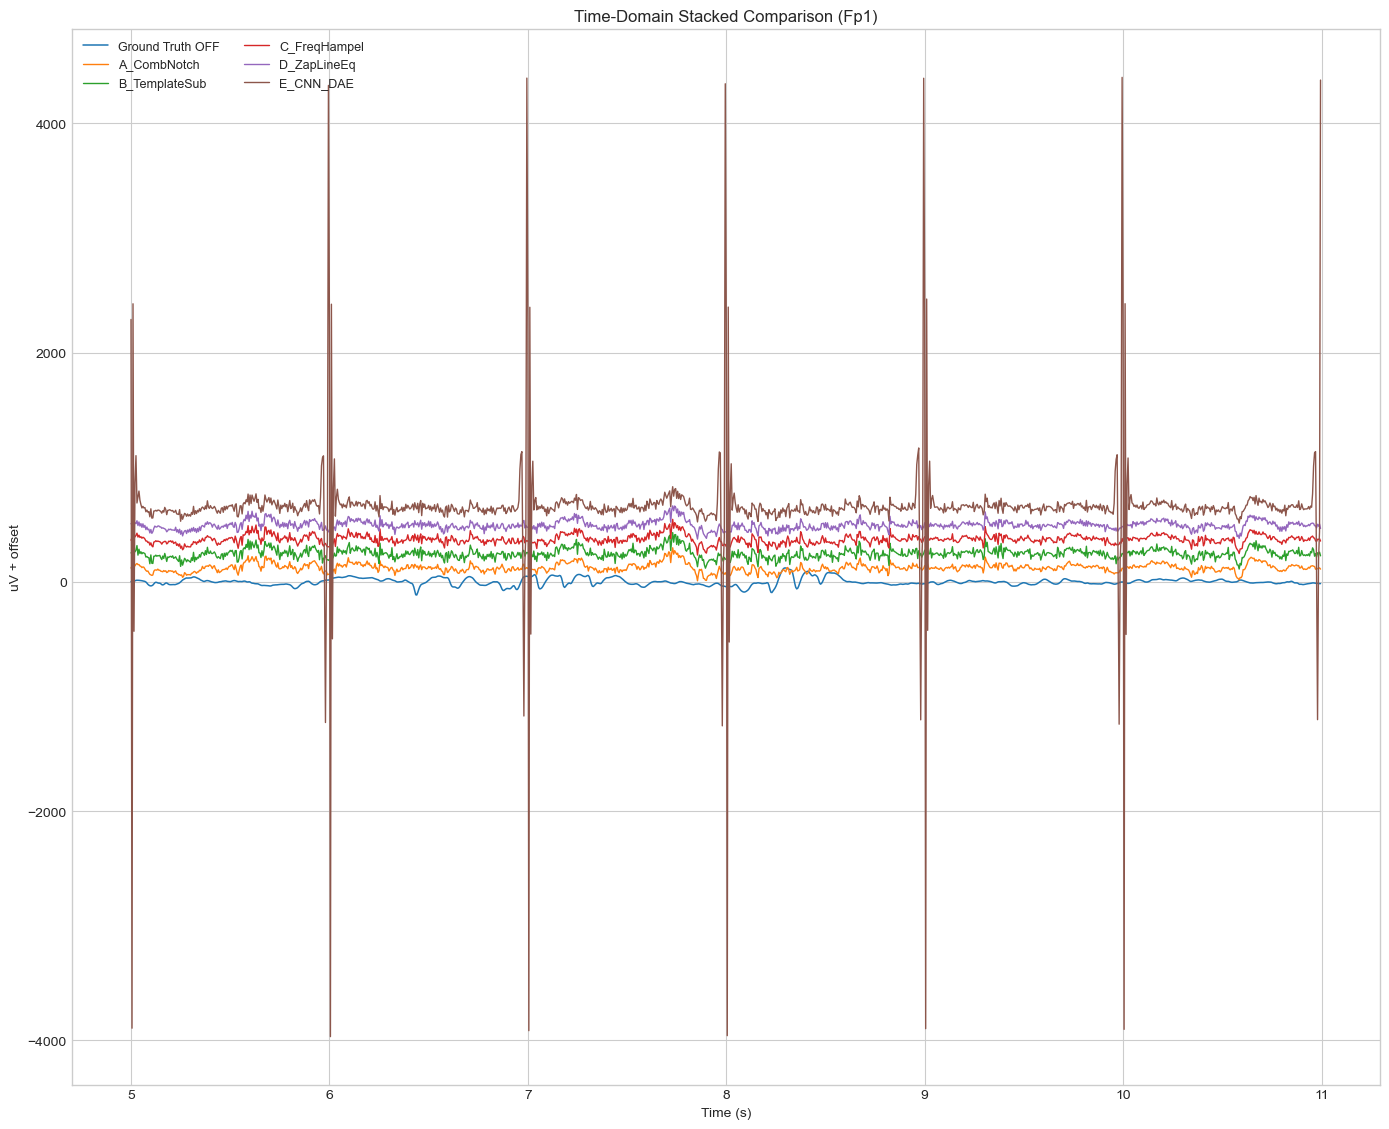

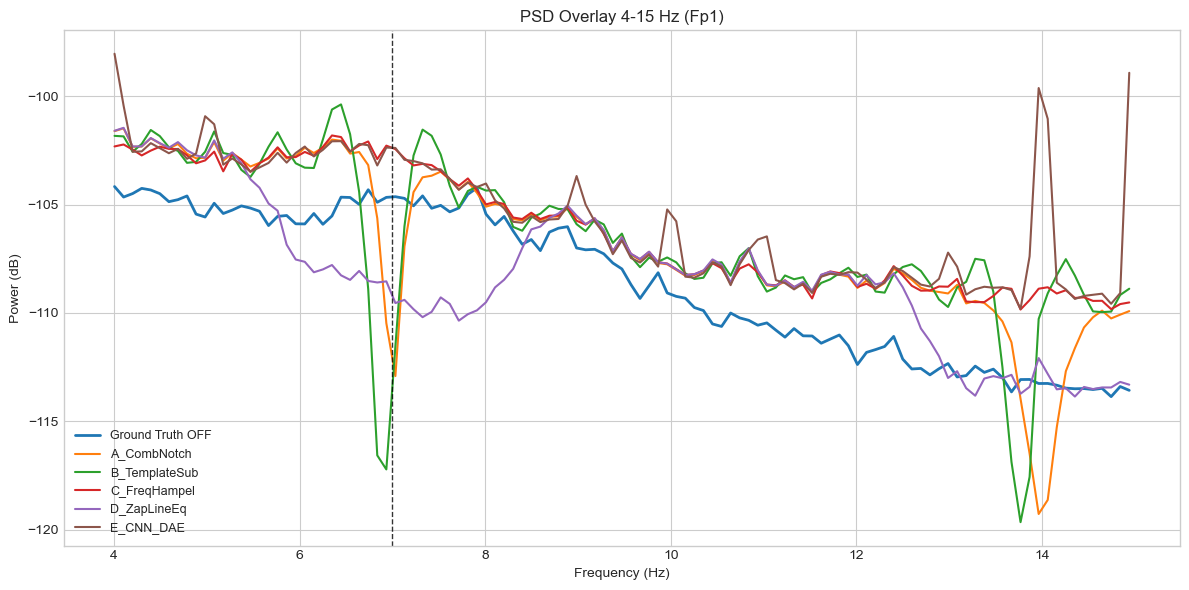

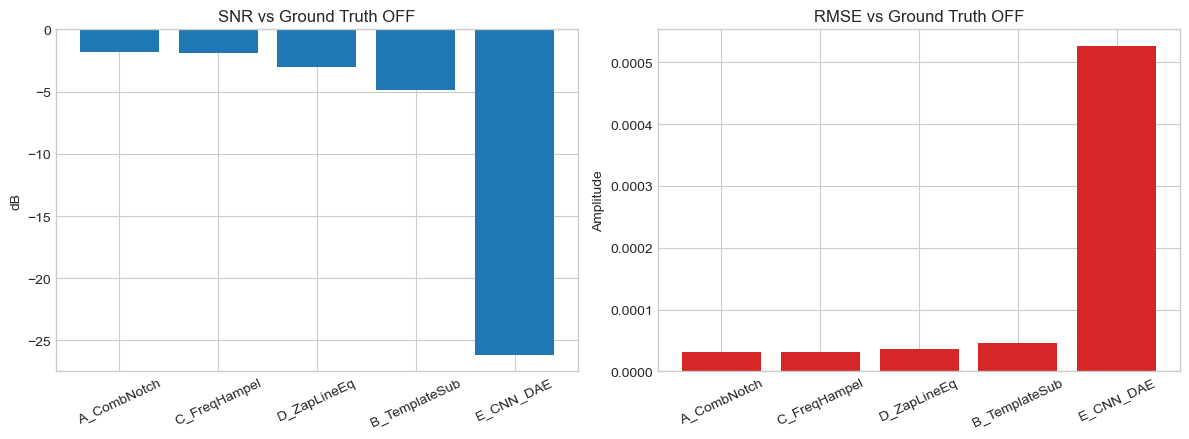

Final verdict
Recommended default method: C_FreqHampel
Composite score: 0.429
Figures saved to: /Users/student/Workspace/ml-driven-eeg-biomarkers/results/figures/dbs_benchmark
Metric caveat: OFF recording is treated as physiological target; mismatch in cognitive state can bias RMSE.


In [60]:
plot_dashboard(raw_off=raw_off, cleaned=methods_ica, metrics_df=metrics_df, cfg=cfg, plot_ch=plot_ch)

# Composite verdict: maximize SNR, minimize RMSE, preserve theta/alpha.
scored = metrics_df.copy()
for col in ["snr_db", "theta_retention_pct", "alpha_retention_pct"]:
    scored[f"z_{col}"] = (scored[col] - scored[col].mean()) / (scored[col].std() + 1e-12)
scored["z_rmse_inv"] = -1.0 * (scored["rmse"] - scored["rmse"].mean()) / (scored["rmse"].std() + 1e-12)
scored["composite_score"] = 0.4 * scored["z_snr_db"] + 0.3 * scored["z_rmse_inv"] + 0.15 * scored["z_theta_retention_pct"] + 0.15 * scored["z_alpha_retention_pct"]

best = scored.sort_values("composite_score", ascending=False).iloc[0]
print("Final verdict")
print(f"Recommended default method: {best['method']}")
print(f"Composite score: {best['composite_score']:.3f}")
print(f"Figures saved to: {cfg.out_fig_dir}")
print("Metric caveat: OFF recording is treated as physiological target; mismatch in cognitive state can bias RMSE.")